# Shoe Object Detection Training Notebook

In [1]:
# If needed:
!pip install tensorflow pillow pandas matplotlib scikit-learn jinja2

In [2]:
import os
import pathlib
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.14.0


In [3]:
# -----------------------------
# Paths and config
# -----------------------------
PROJECT_ROOT = pathlib.Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "dataset"
SHOE_DIR = DATASET_ROOT / "ShoeImages"
NO_SHOE_DIR = DATASET_ROOT / "NoShoeImages"
OUTPUT_DIR = PROJECT_ROOT / "training_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_NAME = "shoe_detector_rgb_native"
SEED = 42
BATCH_SIZE = 16
EPOCHS = 126
VAL_SPLIT = 0.2

CLASS_NAMES = ["NoShoe", "Shoe"]  # label 0, 1

assert SHOE_DIR.exists(), f"Missing folder: {SHOE_DIR}"
assert NO_SHOE_DIR.exists(), f"Missing folder: {NO_SHOE_DIR}"

print("Dataset root:", DATASET_ROOT)
print("Output dir:", OUTPUT_DIR)

Dataset root: c:\Github_School\project-1-visual-object-detectoion-vlipare-ctrl\dataset
Output dir: c:\Github_School\project-1-visual-object-detectoion-vlipare-ctrl\training_outputs


In [ ]:
# -----------------------------
# Number of Images
# -----------------------------
def list_image_files(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

shoe_files = list_image_files(SHOE_DIR)
no_shoe_files = list_image_files(NO_SHOE_DIR)

print("Shoe images:", len(shoe_files))
print("NoShoe images:", len(no_shoe_files))

assert shoe_files, "No images found in ShoeImages"
assert no_shoe_files, "No images found in NoShoeImages"

sample_path = shoe_files[0]

IMAGE_SIZE = (96, 128)
print("Image size (H, W) -- Resized:", IMAGE_SIZE)

Shoe images: 735
NoShoe images: 692
Image size (H, W) -- Resized: (96, 128)


In [5]:
# -----------------------------
# Load datasets
# -----------------------------
train_ds = keras.utils.image_dataset_from_directory(
    DATASET_ROOT,
    labels="inferred",
    label_mode="binary",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="training",
)

val_ds = keras.utils.image_dataset_from_directory(
    DATASET_ROOT,
    labels="inferred",
    label_mode="binary",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="validation",
)

Found 1427 files belonging to 2 classes.
Using 1142 files for training.
Found 1427 files belonging to 2 classes.
Using 285 files for validation.


In [6]:
# -----------------------------
# Performance pipeline
# -----------------------------
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [7]:
# -----------------------------
# Data augmentation
# -----------------------------
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
        layers.RandomContrast(0.15),
    ],
    name="data_augmentation",
)

In [8]:
# -----------------------------
# Model
# -----------------------------
inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), name="input_rgb")

x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 255.0)(x)

# Block 1
x = layers.Conv2D(16, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)

# Block 2
x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)

# Block 3
x = layers.SeparableConv2D(64, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)

# Block 4
x = layers.SeparableConv2D(96, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)

x = layers.Dropout(0.25)(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(1, activation="sigmoid", name="shoe_probability")(x)

model = keras.Model(inputs, outputs, name=MODEL_NAME)
model.summary()

Model: "shoe_detector_rgb_native"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_rgb (InputLayer)      [(None, 96, 128, 3)]      0         
                                                                 
 data_augmentation (Sequent  (None, 96, 128, 3)        0         
 ial)                                                            
                                                                 
 rescaling (Rescaling)       (None, 96, 128, 3)        0         
                                                                 
 conv2d (Conv2D)             (None, 96, 128, 16)       432       
                                                                 
 batch_normalization (Batch  (None, 96, 128, 16)       64        
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 96, 12

In [9]:
# -----------------------------
# Compile
# -----------------------------
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2.4e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

In [10]:
# -----------------------------
# Callbacks
# -----------------------------
checkpoint_path = Path("training_outputs/best_model.h5")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(checkpoint_path),
        monitor='val_accuracy',
        save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
]

In [11]:
# -----------------------------
# Train
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/126
72/72 [==============================] - 7s 64ms/step - loss: 0.6530 - accuracy: 0.6243 - precision: 0.6314 - recall: 0.6194 - val_loss: 0.7341 - val_accuracy: 0.4491 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0024
Epoch 2/126


c:\tf214_hw2\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


72/72 [==============================] - 5s 71ms/step - loss: 0.6109 - accuracy: 0.6506 - precision: 0.6451 - recall: 0.6886 - val_loss: 0.9642 - val_accuracy: 0.4491 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0024
Epoch 3/126
72/72 [==============================] - 5s 68ms/step - loss: 0.5865 - accuracy: 0.6602 - precision: 0.6414 - recall: 0.7457 - val_loss: 1.3927 - val_accuracy: 0.4491 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0024
Epoch 4/126
72/72 [==============================] - 5s 72ms/step - loss: 0.5625 - accuracy: 0.6795 - precision: 0.6626 - recall: 0.7474 - val_loss: 1.4361 - val_accuracy: 0.4491 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0024
Epoch 5/126
72/72 [==============================] - 5s 71ms/step - loss: 0.5622 - accuracy: 0.6944 - precision: 0.6712 - recall: 0.7768 - val_loss: 1.7567 - val_accuracy: 0.4491 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0024
Epoch 6/126
72/72 [=============

In [12]:
best_model = keras.models.load_model("training_outputs/best_model.h5")
val_results = best_model.evaluate(val_ds, verbose=1)
print(val_results)

18/18 [==============================] - 1s 22ms/step - loss: 0.1556 - accuracy: 0.9474 - precision: 0.9277 - recall: 0.9809
[0.15555694699287415, 0.9473684430122375, 0.9277108311653137, 0.9808917045593262]


,loss,accuracy,precision,recall,val_loss,val_accuracy,val_precision,val_recall,lr
121,0.128920,0.952715,0.959649,0.946367,0.185926,0.919298,0.952703,0.898089,0.000002
122,0.118663,0.960595,0.950931,0.972318,0.180853,0.922807,0.953020,0.904459,0.000002
123,0.158649,0.936953,0.936207,0.939446,0.189852,0.919298,0.952703,0.898089,0.000002
124,0.138463,0.959720,0.963415,0.956747,0.191303,0.919298,0.952703,0.898089,0.000002
125,0.120485,0.957093,0.958406,0.956747,0.193669,0.912281,0.952055,0.885350,0.000002


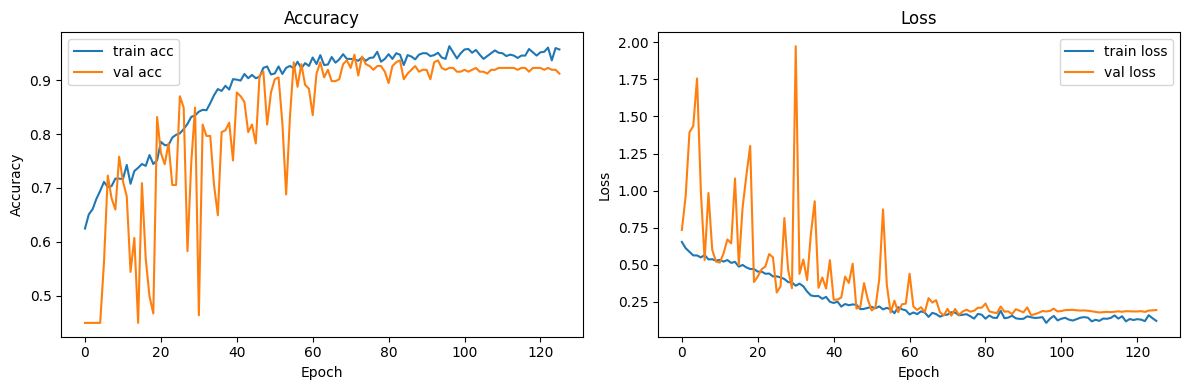

In [13]:
# -----------------------------
# Plot training history
# -----------------------------
history_df = pd.DataFrame(history.history)
display(history_df.tail())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss")

plt.tight_layout()
plt.show()

In [14]:
# -----------------------------
# Save final Keras model
# -----------------------------
keras_model_path = OUTPUT_DIR / f"{MODEL_NAME}_final.keras"
model.save(keras_model_path)
print("Saved Keras model to:", keras_model_path)

Saved Keras model to: c:\Github_School\project-1-visual-object-detectoion-vlipare-ctrl\training_outputs\shoe_detector_rgb_native_final.keras


In [15]:
# -----------------------------
# Quantize to int8 TFLite
# -----------------------------
def representative_data_gen():
    for images, _ in train_ds.take(100):
        for img in images:
            img = tf.cast(img, tf.float32)
            yield [tf.expand_dims(img, axis=0)]

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

tflite_path = OUTPUT_DIR / f"{MODEL_NAME}_int8.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("Saved TFLite model to:", tflite_path)
print("TFLite model size (bytes):", len(tflite_model))

INFO:tensorflow:Assets written to: C:\Users\vipra\AppData\Local\Temp\tmpvbh8c1r3\assets


INFO:tensorflow:Assets written to: C:\Users\vipra\AppData\Local\Temp\tmpvbh8c1r3\assets
c:\tf214_hw2\Lib\site-packages\tensorflow\lite\python\convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved TFLite model to: c:\Github_School\project-1-visual-object-detectoion-vlipare-ctrl\training_outputs\shoe_detector_rgb_native_int8.tflite
TFLite model size (bytes): 36704


In [23]:
# -----------------------------
# Keras & TFLite 
# -----------------------------
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

print("Input quantization:", input_scale, input_zero_point)
print("Output quantization:", output_scale, output_zero_point)

for images, labels in val_ds.take(1):
    test_images = images[:2].numpy()
    test_labels = labels[:2].numpy().astype(int).ravel()

rows = []

for i in range(2):
    img = test_images[i]
    true_label = CLASS_NAMES[test_labels[i]]

    # Keras
    keras_prob = float(best_model.predict(np.expand_dims(img, axis=0), verbose=0)[0][0])
    keras_pred = "Shoe" if keras_prob >= 0.5 else "NoShoe"

    # TFLite
    img_q = np.round(img / input_scale + input_zero_point).astype(np.int8)
    img_q = np.expand_dims(img_q, axis=0)

    interpreter.set_tensor(input_details[0]["index"], img_q)
    interpreter.invoke()

    raw_output = int(interpreter.get_tensor(output_details[0]["index"])[0][0])
    tflite_prob = float((raw_output - output_zero_point) * output_scale)
    tflite_pred = "Shoe" if tflite_prob >= 0.5 else "NoShoe"

    rows.append({
        "Real": true_label,
        "Keras Predicted": keras_pred,
        "Keras Prob": keras_prob,
        "TFLite Predicted": tflite_pred,
        "TFLite Prob": tflite_prob,
        "Raw Int8 Output": raw_output,
    })

results_df = pd.DataFrame(rows)
display(results_df)

Input quantization: 1.0 -128
Output quantization: 0.00390625 -128


,Real,Keras Predicted,Keras Prob,TFLite Predicted,TFLite Prob,Raw Int8 Output
0,Shoe,Shoe,0.992540,Shoe,0.992188,126
1,NoShoe,NoShoe,0.002205,NoShoe,0.000000,-128


In [24]:
# -----------------------------
# Export model as C array (.h)
# -----------------------------
def write_c_array(binary_path, header_path, var_name):
    with open(binary_path, "rb") as f:
        data = f.read()

    with open(header_path, "w") as f:
        f.write("#ifndef MODEL_DATA_H\n")
        f.write("#define MODEL_DATA_H\n\n")
        f.write(f"const unsigned char {var_name}[] = {{\n")

        for i, b in enumerate(data):
            if i % 12 == 0:
                f.write("  ")
            f.write(f"0x{b:02x}")
            if i != len(data) - 1:
                f.write(", ")
            if i % 12 == 11:
                f.write("\n")

        f.write("\n};\n")
        f.write(f"const unsigned int {var_name}_len = {len(data)};\n\n")
        f.write("#endif\n")

header_path = OUTPUT_DIR / "model_data.h"
write_c_array(tflite_path, header_path, f"{MODEL_NAME}_tflite")
print("Saved C header to:", header_path)

Saved C header to: c:\Github_School\project-1-visual-object-detectoion-vlipare-ctrl\training_outputs\model_data.h


In [25]:
# -----------------------------
# Create test_inputs.h
# -----------------------------
img1 = test_images[0]
img2 = test_images[1]

label1 = CLASS_NAMES[test_labels[0]]
label2 = CLASS_NAMES[test_labels[1]]

H, W, C = input_details[0]["shape"][1:4]

img1_q = np.round(img1 / input_scale + input_zero_point).astype(np.int8)
img2_q = np.round(img2 / input_scale + input_zero_point).astype(np.int8)

img1_flat = img1_q.flatten().astype(np.int8)
img2_flat = img2_q.flatten().astype(np.int8)

print("Input1 true label:", label1)
print("Input2 true label:", label2)
print("Height:", H)
print("Width:", W)
print("Channels:", C)
print("Input size:", len(img1_flat))

def write_c_array(f, name, arr):
    f.write(f"const int8_t {name}[{len(arr)}] = {{\n")
    for i, val in enumerate(arr):
        if i % 12 == 0:
            f.write("  ")
        f.write(f"{int(val)}, ")
        if i % 12 == 11:
            f.write("\n")
    f.write("\n};\n\n")

test_inputs_path = OUTPUT_DIR / "test_inputs.h"

with open(test_inputs_path, "w") as f:
    f.write("#ifndef TEST_INPUTS_H\n")
    f.write("#define TEST_INPUTS_H\n\n")

    write_c_array(f, "input1", img1_flat)
    write_c_array(f, "input2", img2_flat)

    f.write(f'const char* input1_label = "{label1}";\n')
    f.write(f'const char* input2_label = "{label2}";\n\n')

    f.write("#endif\n")

print("Created file:", test_inputs_path)

Input1 true label: Shoe
Input2 true label: NoShoe
Height: 96
Width: 128
Channels: 3
Input size: 36864
Created file: c:\Github_School\project-1-visual-object-detectoion-vlipare-ctrl\training_outputs\test_inputs.h


Metric names: ['loss', 'accuracy', 'precision', 'recall']
Train Accuracy: 0.943082332611084
Validation Accuracy: 0.9432623982429504
Test Accuracy: 0.9305555820465088
FRR: 0.025974025974025976
FPR: 0.08955223880597014
Confusion Matrix [[TN, FP], [FN, TP]]:
[[61  6]
 [ 2 75]]


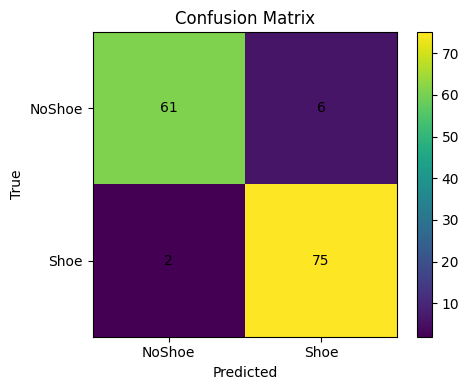

,Metric,Value
0,Train Accuracy,0.943082
1,Validation Accuracy,0.943262
2,Test Accuracy,0.930556
3,FRR,0.025974
4,FPR,0.089552
5,Input Tensor Shape,"(None, 96, 128, 3)"
6,Sampling Rate (FPS),1250904 us


In [29]:
# -----------------------------
# Results
# -----------------------------
from sklearn.metrics import confusion_matrix

val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = max(1, val_batches // 2)

report_test_ds = val_ds.take(test_batches)
report_val_ds = val_ds.skip(test_batches)

train_results = best_model.evaluate(train_ds, verbose=0)
val_results = best_model.evaluate(report_val_ds, verbose=0)
test_results = best_model.evaluate(report_test_ds, verbose=0)

print("Metric names:", best_model.metrics_names)

train_loss = train_results[0]
val_loss = val_results[0]
test_loss = test_results[0]

train_acc = train_results[1]
val_acc = val_results[1]
test_acc = test_results[1]

y_true = []
y_pred = []

for images, labels in report_test_ds:
    probs = best_model.predict(images, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)

    y_true.extend(labels.numpy().ravel().astype(int))
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

frr = fn / (tp + fn) if (tp + fn) > 0 else 0.0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)
print("FRR:", frr)
print("FPR:", fpr)
print("Confusion Matrix [[TN, FP], [FN, TP]]:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], CLASS_NAMES)
plt.yticks([0, 1], CLASS_NAMES)

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

summary_table = pd.DataFrame([
    ["Train Accuracy", train_acc],
    ["Validation Accuracy", val_acc],
    ["Test Accuracy", test_acc],
    ["FRR", frr],
    ["FPR", fpr],
    ["Input Tensor Shape", str(best_model.input_shape)],
    ["Sampling Rate (FPS)", "1250904 us"],
], columns=["Metric", "Value"])

display(summary_table)

In [28]:
# -----------------------------
# Parameters and MACs
# -----------------------------
def estimate_macs(model):
    total_macs = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            out_h, out_w, out_c = layer.output.shape[1], layer.output.shape[2], layer.output.shape[3]
            k_h, k_w = layer.kernel_size
            in_c = layer.input.shape[-1]
            total_macs += int(out_h * out_w * out_c * k_h * k_w * in_c)
        elif isinstance(layer, tf.keras.layers.Dense):
            total_macs += int(layer.input.shape[-1] * layer.units)
    return total_macs

num_params = best_model.count_params()
num_macs = estimate_macs(best_model)

print("Number of Parameters:", num_params)
print("Estimated MACs:", num_macs)

Number of Parameters: 21201
Estimated MACs: 19470400
